In [ ]:
import os
import json
import pandas as pd
from google.colab import drive
from tqdm import tqdm

# 구글 드라이브 마운트
drive.mount('/content/drive')

# 데이터의 최상위 폴더 경로를 지정
# 현재 작업 디렉토리(Agust_Project)를 기준으로 상대 경로 설정
root_directory = './data/한국어 대화 요약'

# 남길 주제 리스트
topics_to_include = ['시사/교육', '일과 직업', '행사']

standard_korean_corpus = []

# os.walk()를 사용하여 모든 하위 폴더와 파일 순회
for dirpath, dirnames, filenames in os.walk(root_directory):
    for filename in filenames:
        if filename.endswith('.json'):
            file_path = os.path.join(dirpath, filename)

            try:
                with open(file_path, 'r', encoding='utf-8') as f:
                    data = json.load(f)

                    # JSON 구조에 따라 'data' 리스트 내의 각 대화(dialog_entry)를 순회
                    for dialog_entry in data['data']:
                        # 'topic' 정보를 확인하여 포함 대상인지 판단
                        topic = dialog_entry['header']['dialogueInfo'].get('topic')

                        if topic in topics_to_include:
                            # 포함할 주제에 해당하는 경우에만 발화(utterance) 추출
                            for utterance in dialog_entry['body']['dialogue']:
                                standard_korean_corpus.append(utterance['utterance'])

            except Exception as e:
                print(f"Error processing {file_path}: {e}")

standard_df = pd.DataFrame(standard_korean_corpus, columns=['text'])

print(f"통합된 표준어 말뭉치 크기: {len(standard_korean_corpus)} 문장")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/인공지능사관학교 6기/Agust_Project
통합된 표준어 말뭉치 크기: 706702 문장


In [ ]:
standard_df['length'] = standard_df['text'].astype(str).apply(lambda x: len(x))

<Axes: ylabel='Count'>

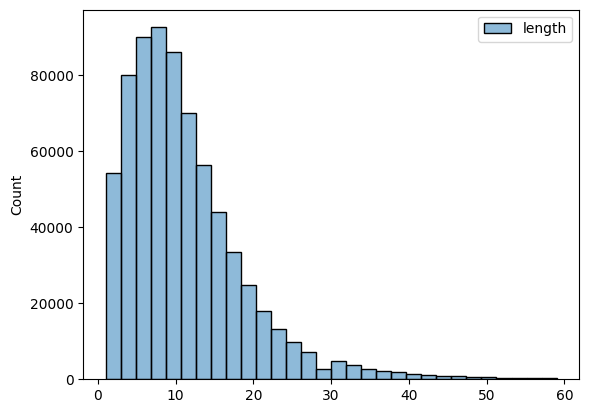

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=standard_df[standard_df['length'] < 60], bins=30)

In [ ]:
filtered_df = standard_df[(standard_df['length'] <= 60) & (standard_df['length'] > 5)]

In [ ]:
len(filtered_df)

526249

In [ ]:
!pip -q install kiwipiepy
from kiwipiepy import Kiwi
import re

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 21.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 119.5 MB/s eta 0:00:00


In [ ]:
# Kiwi 객체 초기화
kiwi = Kiwi()

# 전처리 함수 정의
def preprocess_text(text):
    if pd.isna(text):
        return ""
    spacing_corrected_text = kiwi.space(text)
    clean_text = re.sub(r'[^가-힣0-9\s.,?!]', '', spacing_corrected_text)
    clean_text = re.sub(r'\s+', ' ', clean_text).strip()
    return clean_text

In [ ]:
tqdm.pandas()
filtered_df['text'] = filtered_df['text'].progress_apply(preprocess_text)

100%|██████████| 526249/526249 [04:39<00:00, 1886.19it/s]
/tmp/ipython-input-1409236042.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['text'] = filtered_df['text'].progress_apply(preprocess_text)


In [ ]:
def std_clean_duplicate_data(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:

    # 1. 완전 중복 행 제거 (standard_form과 dialect_form 모두 동일한 경우)
    initial_clean_df = df.drop_duplicates(subset=['text'], keep='first')
    print("완전 중복 제거 후 데이터셋 크기:", len(initial_clean_df))

    return initial_clean_df

In [ ]:
clean_df = std_clean_duplicate_data(filtered_df)

완전 중복 제거 후 데이터셋 크기: 488080


In [81]:
clean_df = clean_df[clean_df['text'] != '']
len(clean_df)

488079

In [82]:
clean_df.to_csv('./data/standard_korean_corpus.csv', index=False, encoding='utf-8-sig')

In [ ]:
from sklearn.model_selection import train_test_split

In [83]:
restoration_data = pd.DataFrame({
    'input_text': '[복원] ' + clean_df['text'].astype(str),
    'target_text': clean_df['text'].astype(str)
})
restoration_train, restoration_test = train_test_split(restoration_data, test_size=0.2, random_state=2003)
restoration_train, restoration_valid = train_test_split(restoration_train, test_size=0.25, random_state=2003)

In [89]:
# 기존 번역 태스크 데이터셋 로드
translation_train = pd.read_csv('./data/preprocessed_train_data.csv')
translation_valid = pd.read_csv('./data/preprocessed_val_data.csv')
translation_test = pd.read_csv('./data/preprocessed_test_data.csv')

# --- 훈련 데이터 병합 ---
# 복원 데이터를 번역 데이터의 1/3 비율로 사용 (조절 가능)
# 복원 데이터가 번역 데이터보다 많을 경우, frac=1.0으로 설정하거나, 번역 데이터 크기에 맞춰 sample()을 사용합니다.
# 예를 들어, restoration_train.sample(n=len(translation_train)//3)
merged_train_df = pd.concat([translation_train, restoration_train.sample(frac=1.0, random_state=2003)], ignore_index=True)

# 데이터를 무작위로 섞음
final_train_df = merged_train_df.sample(frac=1.0, random_state=2003).reset_index(drop=True)

# --- 검증 데이터 병합 ---
# 복원 데이터를 번역 데이터와 동일한 크기로 사용 (전체 사용)
merged_valid_df = pd.concat([translation_valid, restoration_valid], ignore_index=True)
final_valid_df = merged_valid_df.sample(frac=1.0, random_state=2003).reset_index(drop=True)

# --- 테스트 데이터 병합 ---
# 복원 데이터를 번역 데이터와 동일한 크기로 사용 (전체 사용)
merged_test_df = pd.concat([translation_test, restoration_test], ignore_index=True)
final_test_df = merged_test_df.sample(frac=1.0, random_state=2003).reset_index(drop=True)


# 최종 데이터셋 파일로 저장
final_train_df.to_csv('./data/final_train.csv', index=False, encoding='utf-8-sig')
final_valid_df.to_csv('./data/final_valid.csv', index=False, encoding='utf-8-sig')
final_test_df.to_csv('./data/final_test.csv', index=False, encoding='utf-8-sig')

print("최종 훈련 데이터셋 크기:", len(final_train_df))
print("최종 검증 데이터셋 크기:", len(final_valid_df))
print("최종 테스트 데이터셋 크기:", len(final_test_df))

최종 훈련 데이터셋 크기: 1567943
최종 검증 데이터셋 크기: 257002
최종 테스트 데이터셋 크기: 257004


In [88]:
final_test_df[final_test_df['target_text'] == '']

,input_text,target_text
